# Улучшение архитектуры классификатора (Ablation Study)

**Модель:** `DeepPavlov/rubert-base-cased`  
**Данные:** `train_final.csv` → обучение, `test.csv` → оценка  
**Baseline:** balanced accuracy = 0.376, macro F1 = 0.356

**Стратегия:** меняем одно за раз, фиксируем прирост, затем комбинируем лучшие.

**Этап 1 — одиночные улучшения:**
- Exp 1: baseline (воспроизведение)
- Exp 2: Dropout = 0.3
- Exp 3: Сложная голова классификатора
- Exp 4: Дифференцированный LR
- Exp 5: Gradual Unfreezing

**Этап 2 — комбинации лучших (заполнить после этапа 1)**

## 1. Зависимости

In [4]:
%%capture
!pip install transformers torch scikit-learn pandas matplotlib

In [5]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

CUDA: True
GPU: NVIDIA L4
VRAM: 22.0 GB


## 2. Загрузка данных

In [6]:
import random, gc, pandas as pd, numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score

TRAIN_PATH   = Path("/content/train_final.csv")
TEST_PATH    = Path("/content/test.csv")
RESULTS_PATH = Path("/content/ablation_results.csv")

SEED = 42

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

label_encoder = LabelEncoder()
train_df["label_id"] = label_encoder.fit_transform(train_df["label"])
test_df["label_id"]  = label_encoder.transform(test_df["label"])
NUM_LABELS = len(label_encoder.classes_)

print(f"Train: {len(train_df)} | Test: {len(test_df)} | Классов: {NUM_LABELS}")
all_results = []

Train: 2278 | Test: 351 | Классов: 36


## 3. Конфигурация экспериментов

In [7]:
MODEL_NAME = "DeepPavlov/rubert-base-cased"
MAX_LENGTH = 512
BATCH_SIZE = 8
EPOCHS     = 7
BASE_LR    = 2e-5

EXPERIMENTS = [
    {
        "name": "baseline",
        "description": "Базовый классификатор (воспроизведение)",
        "dropout": 0.1,
        "complex_head": False,
        "diff_lr": False,
        "gradual_unfreezing": False,
    },
    {
        "name": "dropout_03",
        "description": "Увеличенный Dropout = 0.3",
        "dropout": 0.3,
        "complex_head": False,
        "diff_lr": False,
        "gradual_unfreezing": False,
    },
    {
        "name": "complex_head",
        "description": "Сложная голова: 2 нелинейности (Linear→GELU→Linear→GELU→Linear)",
        "dropout": 0.1,
        "complex_head": True,
        "diff_lr": False,
        "gradual_unfreezing": False,
    },
    {
        "name": "diff_lr",
        "description": "Дифференцированный LR (embed < lower < upper < head)",
        "dropout": 0.1,
        "complex_head": False,
        "diff_lr": True,
        "gradual_unfreezing": False,
    },
    {
        "name": "gradual_unfreezing",
        "description": "Gradual Unfreezing (по 3 слоя каждые 2 эпохи)",
        "dropout": 0.1,
        "complex_head": False,
        "diff_lr": False,
        "gradual_unfreezing": True,
    },
]

## 4. Архитектура моделей

In [8]:
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


class BertClassifier(nn.Module):
    """Классификатор с поддержкой простой и сложной головы + dropout."""

    def __init__(self, model_name, num_labels, dropout=0.1, complex_head=False):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size

        if complex_head:
            # две нелинейности: 768 -> 384 -> 192 -> num_labels
            self.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden, hidden // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden // 2, hidden // 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden // 4, num_labels),
            )
        else:
            self.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden, num_labels),
            )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return loss, logits


def get_optimizer(model, config, base_lr=BASE_LR):
    """Дифференцированный LR для 12-слойной модели rubert-base."""
    if not config["diff_lr"]:
        return AdamW(model.parameters(), lr=base_lr)

    layers = list(model.bert.named_parameters())
    embed_params = [p for n, p in layers if "embed" in n]
    lower_params = [p for n, p in layers if "layer" in n and
                    any(f"layer.{i}." in n for i in range(6))]
    upper_params = [p for n, p in layers if "layer" in n and
                    any(f"layer.{i}." in n for i in range(6, 12))]
    head_params  = list(model.classifier.parameters())

    return AdamW([
        {"params": embed_params,  "lr": base_lr / 10},
        {"params": lower_params,  "lr": base_lr / 3},
        {"params": upper_params,  "lr": base_lr},
        {"params": head_params,   "lr": base_lr * 5},
    ])


def freeze_bert_layers(model, n_unfreeze_from_top):
    for param in model.bert.parameters():
        param.requires_grad = False
    layers = model.bert.encoder.layer
    for i in range(len(layers) - n_unfreeze_from_top, len(layers)):
        for param in layers[i].parameters():
            param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

## 5. Функция запуска эксперимента

In [9]:
def run_experiment(config):
    set_seed(SEED)
    print("=" * 60)
    print(f'ЭКСПЕРИМЕНТ: {config["name"]}')
    print(f'Описание: {config["description"]}')
    print("=" * 60)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    def tokenize(texts):
        return tokenizer(texts, max_length=MAX_LENGTH, truncation=True,
                         padding="max_length", return_tensors="pt")

    train_enc = tokenize(train_df["text"].tolist())
    test_enc  = tokenize(test_df["text"].tolist())
    train_ds = TextDataset(train_enc, train_df["label_id"].values)
    test_ds  = TextDataset(test_enc,  test_df["label_id"].values)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    model = BertClassifier(MODEL_NAME, NUM_LABELS,
                           dropout=config["dropout"],
                           complex_head=config["complex_head"]).to(device)

    # Gradual unfreezing для 12-слойной модели: стартуем с 3 слоёв, каждые 2 эпохи +3
    if config["gradual_unfreezing"]:
        freeze_bert_layers(model, n_unfreeze_from_top=3)
        total_layers = len(model.bert.encoder.layer)  # 12 для base
        unfreeze_step = len(train_loader) * 2
        unfrozen = 3
        global_step = 0
        print(f"Gradual unfreezing: стартуем с {unfrozen} из {total_layers} слоёв")

    optimizer = get_optimizer(model, config)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=100,
        num_training_steps=len(train_loader) * EPOCHS)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        progress = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS}")
        for batch in progress:
            optimizer.zero_grad()
            loss, _ = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
                labels=batch["labels"].to(device),
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step(); scheduler.step()
            epoch_loss += loss.item()
            progress.set_postfix(loss=loss.item())
            if config["gradual_unfreezing"]:
                global_step += 1
                if global_step % unfreeze_step == 0 and unfrozen < total_layers:
                    unfrozen = min(unfrozen + 3, total_layers)
                    freeze_bert_layers(model, n_unfreeze_from_top=unfrozen)
                    print(f"  Разморожено слоёв: {unfrozen}/{total_layers}")
        print(f"  Эпоха {epoch+1}: loss = {epoch_loss / len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Оценка"):
            _, logits = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            )
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(batch["labels"].numpy())

    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc      = accuracy_score(all_labels, all_preds)

    print(f"\nБалансированная точность: {bal_acc:.4f}")
    print(f"Macro F1:                 {macro_f1:.4f}")
    print(f"Accuracy:                 {acc:.4f}")

    del model, tokenizer, train_enc, test_enc, train_loader, test_loader
    gc.collect(); torch.cuda.empty_cache()

    return {
        "experiment":         config["name"],
        "description":        config["description"],
        "dropout":            config["dropout"],
        "complex_head":       config["complex_head"],
        "diff_lr":            config["diff_lr"],
        "gradual_unfreezing": config["gradual_unfreezing"],
        "balanced_accuracy":  round(bal_acc, 4),
        "macro_f1":           round(macro_f1, 4),
        "accuracy":           round(acc, 4),
    }

## 6. Запуск Этапа 1 — одиночные улучшения

In [10]:
for config in EXPERIMENTS:
    result = run_experiment(config)
    all_results.append(result)
    pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)
    print(f"Сохранено\n")

ЭКСПЕРИМЕНТ: baseline
Описание: Базовый классификатор (воспроизведение)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Разморожено слоёв: 12/12
  Эпоха 6: loss = 0.8874


Эпоха 7/7:   0%|          | 0/285 [00:00<?, ?it/s]

  Эпоха 7: loss = 0.7751


Оценка:   0%|          | 0/44 [00:00<?, ?it/s]


Балансированная точность: 0.4023
Macro F1:                 0.3907
Accuracy:                 0.6211
Сохранено



## 7. Анализ результатов Этапа 1

Прирост относительно baseline (balanced_accuracy = 0.4295):
  baseline                  0.4295  (+0.0000)
  dropout_03                0.4365  (+0.0070)
  complex_head              0.4073  (-0.0222)
  diff_lr                   0.4335  (+0.0040)
  gradual_unfreezing        0.4023  (-0.0272)


/tmp/ipykernel_14263/1811896241.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["experiment"], rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_14263/1811896241.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["experiment"], rotation=30, ha="right", fontsize=8)


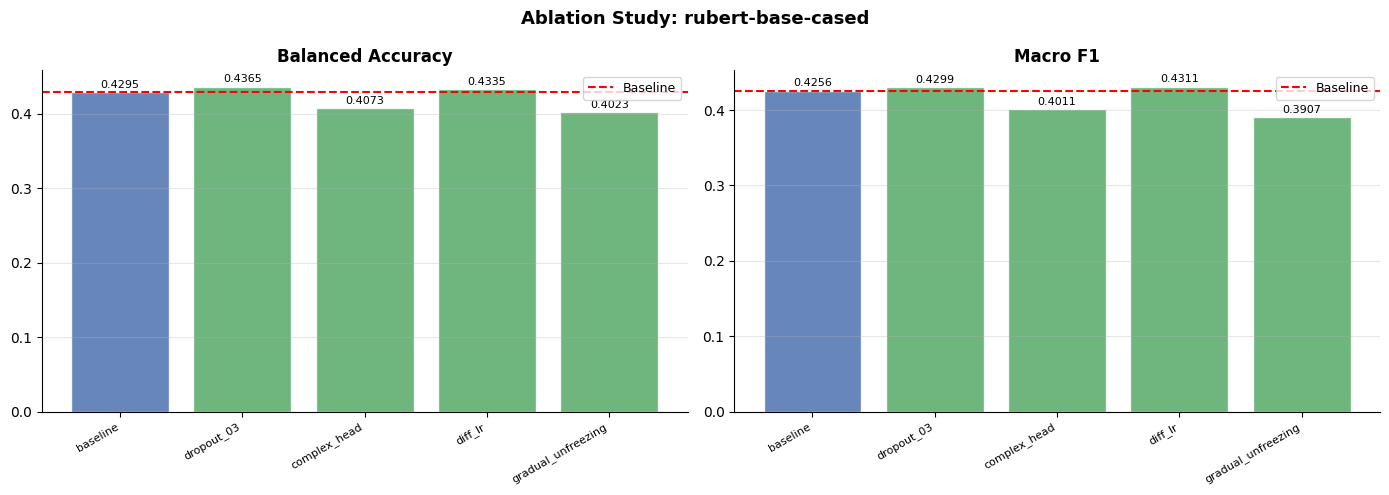


Топ-3 улучшения по Balanced Accuracy:
  experiment  balanced_accuracy  macro_f1
  dropout_03             0.4365    0.4299
     diff_lr             0.4335    0.4311
complex_head             0.4073    0.4011


In [11]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)
baseline_bal = results_df[results_df["experiment"]=="baseline"]["balanced_accuracy"].values[0]
baseline_f1  = results_df[results_df["experiment"]=="baseline"]["macro_f1"].values[0]

print(f"Прирост относительно baseline (balanced_accuracy = {baseline_bal}):")
for _, row in results_df.iterrows():
    delta = row["balanced_accuracy"] - baseline_bal
    print(f'  {row["experiment"]:<25} {row["balanced_accuracy"]:.4f}  ({delta:+.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ["balanced_accuracy", "macro_f1"], ["Balanced Accuracy", "Macro F1"]):
    colors = ["#4C72B0" if r=="baseline" else "#55A868" for r in results_df["experiment"]]
    bars = ax.bar(results_df["experiment"], results_df[metric],
                  color=colors, alpha=0.85, edgecolor="white")
    ref = baseline_bal if metric=="balanced_accuracy" else baseline_f1
    ax.axhline(y=ref, color="red", linestyle="--", linewidth=1.5, label="Baseline")
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(results_df["experiment"], rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle("Ablation Study: rubert-base-cased", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nТоп-3 улучшения по Balanced Accuracy:")
top = results_df[results_df["experiment"]!="baseline"].nlargest(3, "balanced_accuracy")
print(top[["experiment", "balanced_accuracy", "macro_f1"]].to_string(index=False))

## 8. Этап 2 — Комбинации лучших улучшений

После анализа результатов Этапа 1 — раскомментируй лучшие комбинации и запусти.

In [10]:
COMBO_EXPERIMENTS = [
    # Комбо 1 — только победители Этапа 1 (dropout_03 + diff_lr)
    {"name": "combo_winners", "description": "dropout 0.3 + diff_lr (победители Этапа 1)",
     "dropout": 0.3, "complex_head": False, "diff_lr": True, "gradual_unfreezing": False},

    # Комбо 2 — dropout + 2 нелинейности + diff_lr
    {"name": "combo1", "description": "dropout 0.3 + сложная голова (2 нелин.) + diff_lr",
     "dropout": 0.3, "complex_head": True, "diff_lr": True, "gradual_unfreezing": False},
]

for config in COMBO_EXPERIMENTS:
    result = run_experiment(config)
    all_results.append(result)
    pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)
    print(f"Сохранено: {config['name']}\n")

print("Итоговая таблица:")
print(pd.read_csv(RESULTS_PATH)[["experiment", "balanced_accuracy", "macro_f1"]].to_string(index=False))

ЭКСПЕРИМЕНТ: combo_winners
Описание: dropout 0.3 + diff_lr (победители Этапа 1)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Эпоха 6: loss = 1.1773


Эпоха 7/7:   0%|          | 0/285 [00:00<?, ?it/s]

  Эпоха 7: loss = 1.0387


Оценка:   0%|          | 0/44 [00:00<?, ?it/s]


Балансированная точность: 0.4178
Macro F1:                 0.3831
Accuracy:                 0.5783
Сохранено: combo_pavel

Итоговая таблица:
   experiment  balanced_accuracy  macro_f1
combo_winners             0.4329    0.4280
  combo_pavel             0.4178    0.3831


In [11]:
from google.colab import files
files.download("/content/ablation_results.csv")
files.download("/content/ablation_results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/ablation_results.png